In [2]:
import exchange_calendars as xcals
import matplotlib.pyplot as plt
from datetime import datetime

Календарь не задан для Shenzhen Stock Exchange; пропускаем.


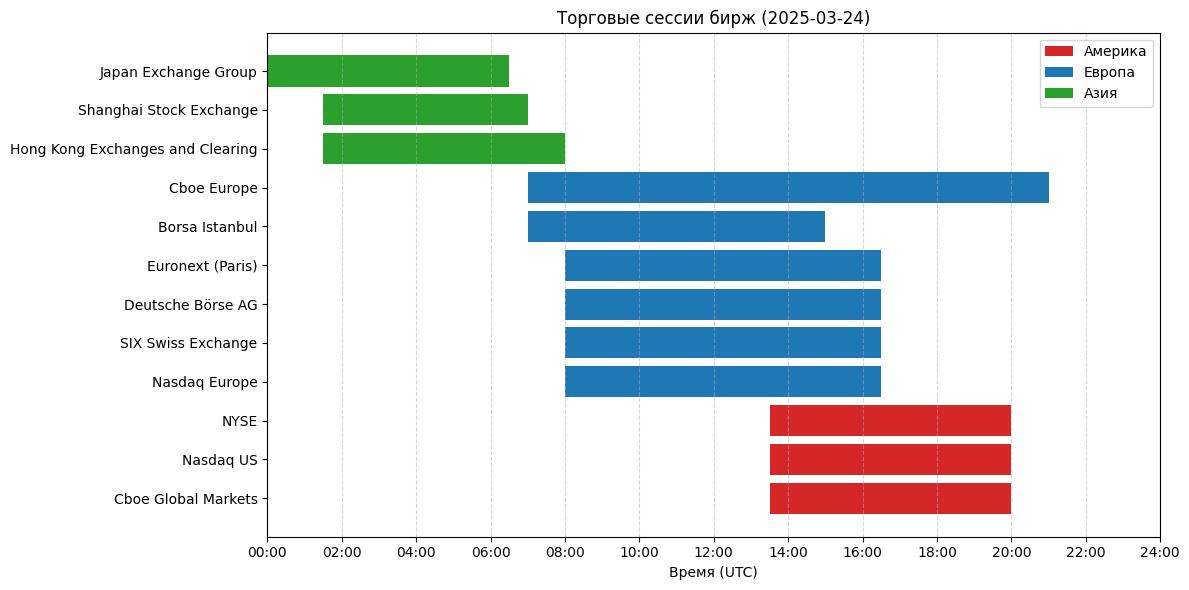

In [ ]:


# =========================
# ВЫБЕРИ ДАТУ
# =========================
date = "2025-03-24"

# =========================
# СООТВЕТСТВИЕ БИРЖ КАЛЕНДАРЯМ
# =========================
exchanges = [
    # Америка
    ("NYSE", "XNYS", "US"),
    ("Nasdaq US", "XNAS", "US"),
    ("Cboe Global Markets", "BATS", "US"),  # proxy

    # Европа
    ("Euronext (Paris)", "XPAR", "EU"),
    ("Deutsche Börse AG", "XETR", "EU"),
    ("SIX Swiss Exchange", "XSWX", "EU"),
    ("Cboe Europe", "XEUR", "EU"),  # proxy, прямого календаря нет
    ("Borsa Istanbul", "XIST", "EU"),
    ("Nasdaq Stockholm", "XSTO", "EU"),
    ("Nasdaq Helsinki", "XHEL", "EU"),
    ("Nasdaq Riga", "XRIS", "EU"),
    ("Nasdaq Warsaw", "XWAR", "EU"),
    ("Nasdaq Vilnius", "XWBO", "EU"),

    # Азия
    ("Shanghai Stock Exchange", "XSHG", "Asia"),
    ("Japan Exchange Group", "JPX", "Asia"),
    ("Hong Kong Exchanges and Clearing", "HKEX", "Asia"),
]

# =========================
# ЦВЕТА
# =========================
colors = {
    "US": "#d62728",
    "EU": "#1f77b4",
    "Asia": "#2ca02c"
}

sessions = []
nasdaq_eu_sessions = []

# =========================
# ПОЛУЧАЕМ РАСПИСАНИЕ
# =========================
for name, cal_code, region in exchanges:
    if cal_code is None:
        print(f"Календарь не задан для {name}; пропускаем.")
        continue

    try:
        cal = xcals.get_calendar(cal_code)
    except Exception as exc:
        print(f"Календарь {cal_code} не найден для {name}: {exc}")
        continue
    
    sched = cal.schedule.loc[date:date]
    
    if sched.empty:
        continue  # выходной
    
    open_time = sched.iloc[0]["open"]
    close_time = sched.iloc[0]["close"]
    
    # перевод в UTC часы
    start = open_time.hour + open_time.minute / 60
    end = close_time.hour + close_time.minute / 60
    if region == "EU" and name.startswith("Nasdaq"):
        nasdaq_eu_sessions.append((name, start, end, region))
    else:
        sessions.append((name, start, end, region))

if nasdaq_eu_sessions:
    start = min(item[1] for item in nasdaq_eu_sessions)
    end = max(item[2] for item in nasdaq_eu_sessions)
    sessions.append(("Nasdaq Europe", start, end, "EU"))

# =========================
# СТРОИМ ГРАФИК
# =========================
fig, ax = plt.subplots(figsize=(12, 6))

sessions.sort(key=lambda item: item[1])

for i, (name, start, end, region) in enumerate(sessions):
    ax.barh(i, end - start, left=start, color=colors[region])

ax.set_yticks(range(len(sessions)))
ax.set_yticklabels([s[0] for s in sessions])
ax.invert_yaxis()

ax.set_xlim(0, 24)
ax.set_xticks(list(range(0, 25, 2)))
ax.set_xticklabels([f"{hour:02d}:00" for hour in range(0, 25, 2)])
ax.set_xlabel("Время (UTC)")
ax.set_title(f"Торговые сессии бирж ({date})")

# легенда
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors["US"], label="Америка"),
    Patch(facecolor=colors["EU"], label="Европа"),
    Patch(facecolor=colors["Asia"], label="Азия"),
]
ax.legend(handles=legend_elements)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

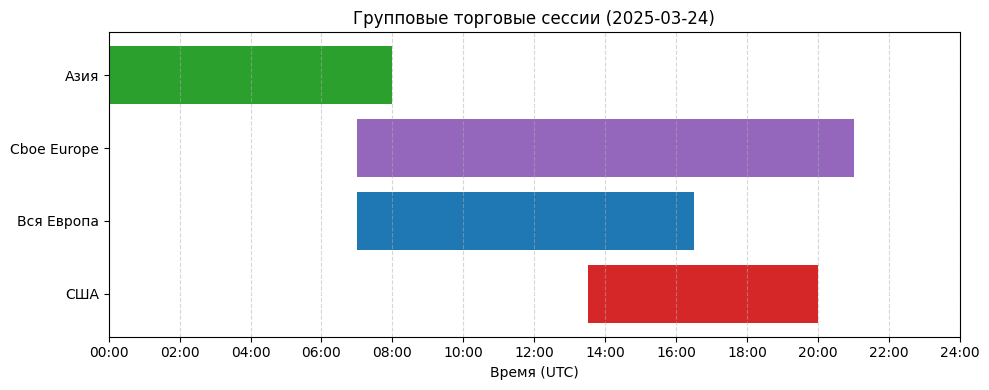

In [6]:
# =========================
# ГРУППЫ БИРЖ
# =========================
group_definitions = [
    ("Азия", lambda item: item[3] == "Asia"),
    ("Cboe Europe", lambda item: item[0] == "Cboe Europe"),
    ("Вся Европа", lambda item: item[3] == "EU" and item[0] != "Cboe Europe"),
    ("США", lambda item: item[3] == "US"),
]

group_sessions = []
for group_name, matcher in group_definitions:
    matched = [item for item in sessions if matcher(item)]
    if not matched:
        print(f"Группа '{group_name}' не содержит сессий для даты {date}.")
        continue

    start = min(item[1] for item in matched)
    end = max(item[2] for item in matched)
    group_sessions.append((group_name, start, end))

colors_by_group = {
    "Азия": colors["Asia"],
    "Cboe Europe": "#9467bd",
    "Вся Европа": colors["EU"],
    "США": colors["US"],
}

fig, ax = plt.subplots(figsize=(10, 4))
for idx, (group_name, start, end) in enumerate(group_sessions):
    ax.barh(idx, end - start, left=start, color=colors_by_group.get(group_name, "#7f7f7f"))

ax.set_yticks(range(len(group_sessions)))
ax.set_yticklabels([group_name for group_name, _, _ in group_sessions])
ax.invert_yaxis()

ax.set_xlim(0, 24)
ax.set_xticks(list(range(0, 25, 2)))
ax.set_xticklabels([f"{hour:02d}:00" for hour in range(0, 25, 2)])
ax.set_xlabel("Время (UTC)")
ax.set_title(f"Групповые торговые сессии ({date})")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()